# PyTorch tools

#### Imports

In [1]:
# !pip install torch torchvision

In [2]:
import pathlib

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [3]:
torch.manual_seed(25)

As usual, we could set the device to "cuda" or "cpu" according to what your computer has. But for now, we won't really need GPUs, so we are not going to bother manipulating `.to_device()` (if we don't, it'll go to the CPU by default). You should understand where to put `.to_device()` if you want to use your GPU but it's not the point of this TD, one step at a time ...

#### Data

Before we begin, let's gather some data.
Like a chef preparing ingredients before cooking, the data has already been set aside for us by the assistants.

We'll start with a small dataset, as our goal isn't to train the largest model or use the largest dataset just yet. The data we'll be using is a subset of the `Food101` ([credit where it's due](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)) dataset plus some we added ourselves. This dataset is a popular benchmark in computer vision, as it contains 1,000 images of 101 different types of food, for a total of 101,000 images (75,750 for training and 25,250 for testing).

Instead of 101 food classes though, we're going to start with 3: pizza, steak and sushi.

Download the whole pizza / steak / sushi dataset [here](https://drive.google.com/file/d/1JNiqVEbaOyRIWLc3UwHS4Y6CO60wx1iu/view?usp=sharing) and un-zip it. This is probably what will take you 60% of your time if you do Applied Deep Learning in the real world. But it's here it's pretty much ready.

If you look at the new folder on your computer, all images of pizza are contained in the `pizza/` directory.

This format (putting images of a class in a folder the name of which is the class name) is popular across many different image classification benchmarks, including [ImageNet](https://www.image-net.org/) (of the most popular computer vision benchmark datasets).

In [4]:
# Setup train and testing paths
data_path = pathlib.Path("../data/")
train_dir = data_path / "Food-3/train"
test_dir = data_path / "Food-3/test"

train_dir, test_dir

(PosixPath('../data/Food-3/train'), PosixPath('../data/Food-3/test'))

Take a closer look at the images. There is a problem, can you spot it? The images do not all have the same dimension! We are therefore going to learn how to resize images with `torchvision.transforms` (this can do a lot more, but today we're only resizing images).

In [5]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(),
    # transforms.Grayscale()
    ]
)

We will not create a `CustomDataSet` with `class CustomDataset(Dataset)` like we did in the TD 2a. Because when we deal with images, audios, etc ... nicely put in folders, there exist classes already implemented that we can use. But the way they're implemented in PyTorch is similar to how we implemented our own `CustomDataSet` inhereting from the abstract* class `Dataset`.

\* an Abstract Class is a Class we do not want to (and cannot) instantiate. We only want to inherit from it.

Let's use the class [`torchvision.datasets.ImageFolder`](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder), built-in PyTorch.

In [6]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None,
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform,
    target_transform=None,
)
train_data.classes

['pizza', 'steak', 'sushi']

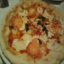

In [7]:
train_data[0][0]

In [8]:
train_data.classes[train_data[0][1]]

'pizza'

The Class `ImageFolder` inherits from `DatasetFolder` which inherits from `VisionDataset` which has a nice method to redefine what happens when we print the object (see below!). When custom classes exist, except if you're ready to spend hours of work and you're a senior software engineer, it's usually better to take classes that are already built in.

In [9]:
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 2712
    Root location: ../data/Food-3/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 306
    Root location: ../data/Food-3/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
           )


---
As a comparison, what we got from printing our CustomDataset last time is not great:


In [10]:
import numpy as np
from torch.utils.data import Dataset

# Data Generation
np.random.seed(42)
xs = np.random.rand(100, 1)
ys = 1 + 2 * xs + .1 * np.random.randn(100, 1)

class CustomDataset(Dataset):
    def __init__(self, x_tensor, y_tensor):
        self.x = x_tensor
        self.y = y_tensor

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)

xs_tensor = torch.from_numpy(xs).float()
ys_tensor = torch.from_numpy(ys).float()

train_data_custom = CustomDataset(xs_tensor, ys_tensor)
print(train_data_custom)

---
Let's look at one element of our object `train_data`.

In [11]:
train_data[0]

(<PIL.Image.Image image mode=RGB size=64x64>, 0)

We don't have a tensor! That's because, we didn't tell PyTorch to transform it into a tensor. It's not automatic. Let's rewrite our function `data_transform`:

In [12]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Grayscale()
    ]
)

If we look at the [torchvision.transforms.ToTensor() documentation](https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html), we can see that instead of the standard pixel values from 0 to 255, we will get values from 0.0 and 1.0.

Let's recreate our objects `train_data` and `test_data`:

In [13]:
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None,
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform,
    target_transform=None,
)
train_data.classes

['pizza', 'steak', 'sushi']

In [14]:
train_data[0]

(tensor([[[0.2196, 0.2392, 0.1490,  ..., 0.2471, 0.2118, 0.1765],
          [0.2549, 0.2784, 0.1804,  ..., 0.1137, 0.1490, 0.2314],
          [0.2824, 0.2549, 0.2157,  ..., 0.2275, 0.3804, 0.4353],
          ...,
          [0.5373, 0.5098, 0.2706,  ..., 0.2196, 0.3412, 0.4431],
          [0.5020, 0.5020, 0.3608,  ..., 0.3412, 0.4471, 0.4549],
          [0.4510, 0.4549, 0.4078,  ..., 0.4510, 0.4627, 0.4392]],
 
         [[0.2314, 0.2588, 0.1608,  ..., 0.2627, 0.2275, 0.1922],
          [0.2627, 0.2980, 0.1922,  ..., 0.1255, 0.1608, 0.2471],
          [0.2902, 0.2745, 0.2275,  ..., 0.2392, 0.4000, 0.4588],
          ...,
          [0.5843, 0.5490, 0.2745,  ..., 0.2157, 0.3765, 0.4980],
          [0.5373, 0.5373, 0.3765,  ..., 0.3725, 0.5020, 0.5137],
          [0.4745, 0.4784, 0.4275,  ..., 0.5059, 0.5176, 0.4980]],
 
         [[0.1490, 0.1765, 0.1098,  ..., 0.2157, 0.1804, 0.1451],
          [0.1765, 0.2078, 0.1333,  ..., 0.0980, 0.1176, 0.1922],
          [0.1961, 0.1804, 0.1569,  ...,

Is 0 pizza, steak or sushi? Our object `torchvision.datasets.ImageFolder` has a useful attribute `classes`.

In [15]:
train_data.classes

['pizza', 'steak', 'sushi']

It's a pizza.

In [16]:
train_data[0][0].shape

torch.Size([3, 64, 64])

In [17]:
train_data[0][0].permute(1,2,0).shape

torch.Size([64, 64, 3])

Our images are now in the form of a tensor with shape `[3, 64, 64]`. If we want to plot them, it's possible, however, `matplotlib` wants `HWC` (Height, Width, Color channels), therefore we need to reshape `[3, 64, 64]` in `[64, 64, 3]`. This is something you should feel comfortable doing (this StackOverflow answer can help https://stackoverflow.com/a/51145633/11092636 understanding the two main methods `.permute` and `.view`; here we want to swap axes, we will therefore use `.permute`).

In [18]:
one_pizza = train_data[0][0]
one_pizza_reshaped = one_pizza.permute(1,2,0)

one_pizza_reshaped.shape

torch.Size([64, 64, 3])

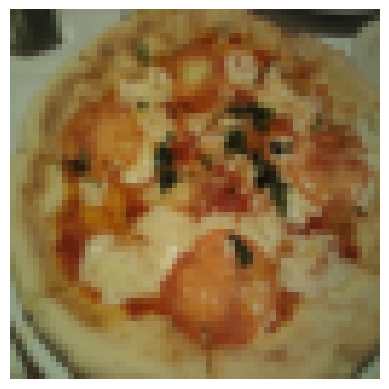

In [19]:
plt.imshow(one_pizza_reshaped)
plt.axis('off')
plt.show()

If you remember correctly last TD, after getting our data as a PyTorch `Dataset` we need to turn them into a `DataLoader`.

We'll do so using [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

Reminder: turning our `Dataset`'s into `DataLoader`'s makes them iterable so a model can go through learn the relationships between samples and targets (features and labels).

To keep things simple, we'll use a `batch_size=1`.

In [20]:
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=16,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=4,
    shuffle=False
)


In [21]:
class Net(nn.Module):
    def __init__(self, n_hidden=200):
        super().__init__()
        self.fc1 = nn.Linear(64*64*3, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        return x

model = Net()

In [22]:
train_data[0][1]

0

In [23]:
torch.argmax(model(torch.randn(12288)))


tensor(2)

Let's do a forward pass to test the model when it's not been trained.

In [24]:
def test_model(model):
    model.eval()
    test_acc = 0.0
    with torch.no_grad():
        for x_test, y_test in test_dataloader:
            model_output = model(x_test.view(-1, 64*64*3))
            model_pred = torch.argmax(model_output, dim=1)
            test_acc += (model_pred == y_test).sum()
    test_acc /= len(test_data)
    return test_acc

test_model(model)

tensor(0.3170)

Let's train the model

In [25]:
def train(model, optimizer, loss_fn=nn.CrossEntropyLoss(), n_epochs=10):
    model.train()

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        epoch_correct_count = 0.0
        for x_train, y_train in train_dataloader:
            y_pred = model(x_train.view(-1, 64*64*3))
            class_pred = torch.argmax(y_pred, dim=1)
            epoch_correct_count += (class_pred == y_train).sum()
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            epoch_loss += loss.item()
            optimizer.step()
            optimizer.zero_grad()
        epoch_acc = epoch_correct_count / len(train_data)
        print(f"Epoch {epoch+1} / {n_epochs}: loss={epoch_loss}, accuracy={epoch_acc}")


model = Net()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train(model, optimizer)

Epoch 1 / 10: loss=195.2937007546425, accuracy=0.4992625415325165
Epoch 2 / 10: loss=154.2574605345726, accuracy=0.5527285933494568
Epoch 3 / 10: loss=150.30672681331635, accuracy=0.5663716793060303
Epoch 4 / 10: loss=147.8285493850708, accuracy=0.5851770043373108
Epoch 5 / 10: loss=148.55275866389275, accuracy=0.5859144330024719
Epoch 6 / 10: loss=144.49928921461105, accuracy=0.6165191531181335
Epoch 7 / 10: loss=142.0556667149067, accuracy=0.6120944023132324
Epoch 8 / 10: loss=141.61679849028587, accuracy=0.6143068075180054
Epoch 9 / 10: loss=139.80776190757751, accuracy=0.6308997273445129
Epoch 10 / 10: loss=138.7659334242344, accuracy=0.6294247508049011


In [26]:
test_model(model)

tensor(0.5359)

In [27]:
def train(model, optimizer, loss_fn=nn.CrossEntropyLoss(), n_epochs=10):
    model.train()

    for epoch in range(n_epochs):
        epoch_loss = 0.0
        epoch_correct_count = 0.0
        for x_train, y_train in train_dataloader:
            y_pred = model(x_train.view(-1, 64*64*3))
            class_pred = torch.argmax(y_pred, dim=1)
            epoch_correct_count += (class_pred == y_train).sum()
            loss = loss_fn(y_pred, y_train)
            loss.backward()
            epoch_loss += loss.item()
            optimizer.step()
            optimizer.zero_grad()
        epoch_acc = epoch_correct_count / len(train_data)
        print(f"Epoch {epoch+1} / {n_epochs}: loss={epoch_loss}, accuracy={epoch_acc}")


model = Net()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
train(model, optimizer)

Epoch 1 / 10: loss=175.02355915308, accuracy=0.5003687143325806
Epoch 2 / 10: loss=161.96923100948334, accuracy=0.5523598790168762
Epoch 3 / 10: loss=156.54935312271118, accuracy=0.5671091675758362
Epoch 4 / 10: loss=154.0531707406044, accuracy=0.5785398483276367
Epoch 5 / 10: loss=152.11774092912674, accuracy=0.5825958847999573
Epoch 6 / 10: loss=151.08336675167084, accuracy=0.5807521939277649
Epoch 7 / 10: loss=150.25391948223114, accuracy=0.5870206356048584
Epoch 8 / 10: loss=148.87005493044853, accuracy=0.5940265655517578
Epoch 9 / 10: loss=148.027885556221, accuracy=0.6017699241638184
Epoch 10 / 10: loss=146.96126681566238, accuracy=0.5936577916145325


In [28]:
test_model(model)

tensor(0.5686)

We will "scale up" the number of images in the next class, and we will add some techniques we've seen in the class today to try and improve even more our accuracy!!

Keep in mind though, if you train your data on both optimizers and decide you picked one optimizer because the accuracy on your testing set is better with that optimizer, you've effectively got information from the testing dataset which is not independent anymore, it has therefore inherently become a validation set; and you need an extra independent validation set.

It's just numbers though, let's check the predictions are actually correct on some examples by showing the images, the expected label and the predicted label.

In [29]:
img, label = test_data[0]
logits = model(img.view(1, -1))
logits

tensor([[ 0.9417, -0.6801,  0.1470]], grad_fn=<AddmmBackward0>)

In [30]:
pred_int = torch.argmax(logits)
pred_class = test_data.classes[pred_int]
correct_class = test_data.classes[label]
pred_class, correct_class

('pizza', 'pizza')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

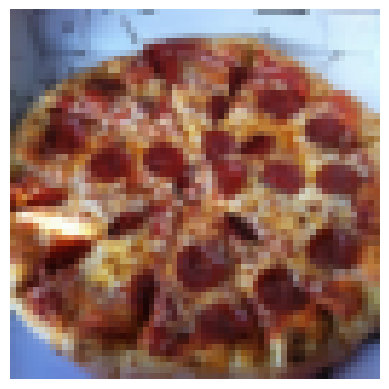

In [31]:
plt.imshow(img.permute(1,2,0))
plt.axis('off')